In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','GOOG'), 
         ('CRH','META'), 
         ('CRH','TSLA'), 
         ('TDG','GOOG'), 
         ('TDG', 'META'),
         ('TDG', 'TSLA'), 
         ('NEM','GOOG'), 
         ('NEM', 'META'), 
         ('NEM','TSLA')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

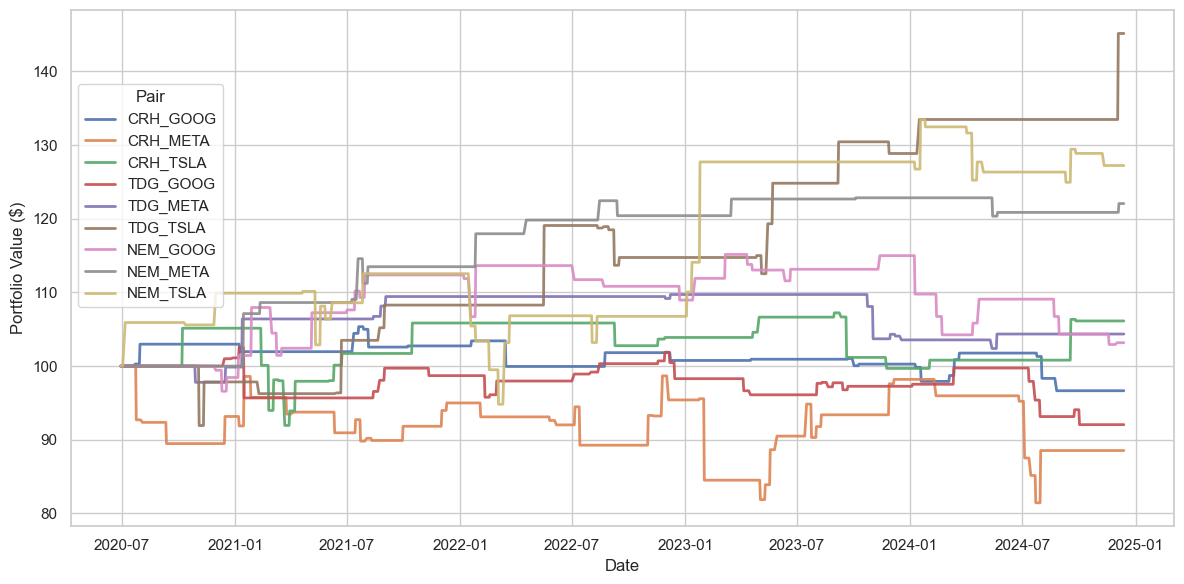

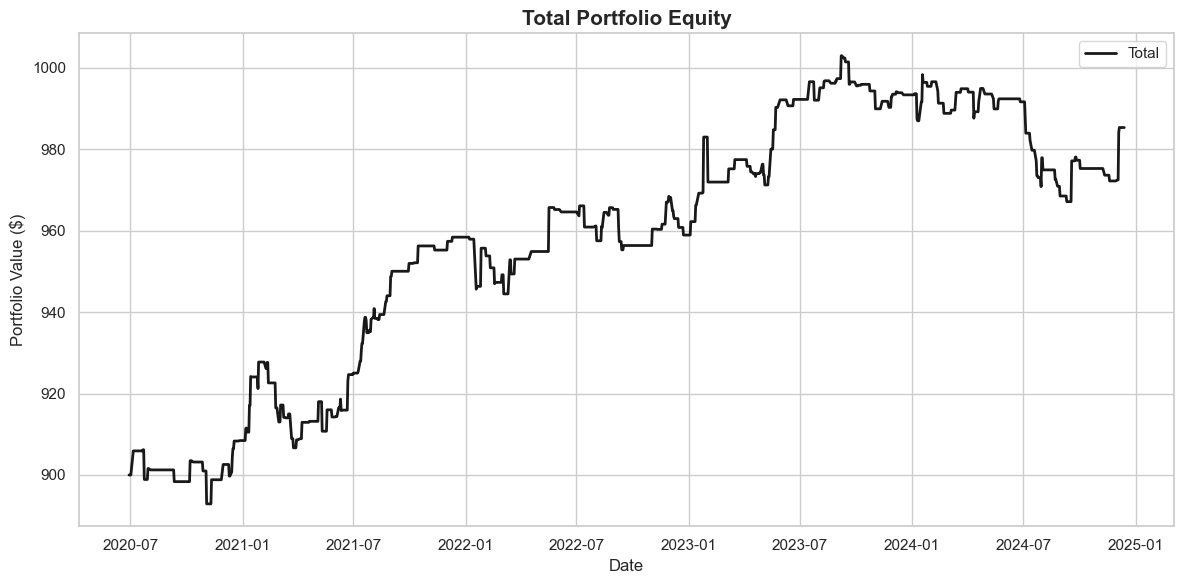

Summary
CRH_GOOG: Final Value = $96.66, Total Return = -3.34%, Trades = 24
CRH_META: Final Value = $88.54, Total Return = -11.46%, Trades = 44
CRH_TSLA: Final Value = $106.13, Total Return = 6.13%, Trades = 24
TDG_GOOG: Final Value = $92.05, Total Return = -7.95%, Trades = 34
TDG_META: Final Value = $104.35, Total Return = 4.35%, Trades = 15
TDG_TSLA: Final Value = $145.14, Total Return = 45.14%, Trades = 21
NEM_GOOG: Final Value = $103.17, Total Return = 3.17%, Trades = 35
NEM_META: Final Value = $122.06, Total Return = 22.06%, Trades = 15
NEM_TSLA: Final Value = $127.22, Total Return = 27.22%, Trades = 31

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $985.33
Total Return:            9.48%

Sharpe Ratios
CRH_GOOG: Sharpe Ratio = -0.19
CRH_META: Sharpe Ratio = -0.15
CRH_TSLA: Sharpe Ratio = 0.21
TDG_GOOG: Sharpe Ratio = -0.35
TDG_META: Sharpe Ratio = 0.25
TDG_TSLA: Sharpe Ratio = 0.87
NEM_GOOG: Sharpe Ratio = 0.13
NEM_META: Sharpe Ratio = 0.87
N

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)